# 01 — Setup & Funnel Analysis
### Product Analytics & Experimentation — E-Commerce Funnel

**Business question:** Where do we lose customers in the order journey, and who is most affected?

**North-star metric:** repeat-purchase rate — the share of *unique* customers with more than one order.

**Guardrail metrics:** delivery time, review score.

> **Data gotcha (important):** in this dataset `customer_id` is assigned *per order*, not per person.
> The column that identifies a real repeat customer across orders is **`customer_unique_id`**
> (it lives in the `customers` table). Use the wrong one and every retention number will be wrong.


## 1. Setup — imports, connect, load the CSVs into DuckDB

Run this once. It creates a local `olist.duckdb` file and loads every CSV into a table.

In [3]:
%pip install duckdb pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Connect to a local DuckDB file (created if it doesn't exist).
con = duckdb.connect("../olist.duckdb")

# Map friendly table names -> CSV filenames in ../data/
tables = {
    "orders":    "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "items":     "olist_order_items_dataset.csv",
    "payments":  "olist_order_payments_dataset.csv",
    "reviews":   "olist_order_reviews_dataset.csv",
}

for name, file in tables.items():
    con.execute(
        f"CREATE OR REPLACE TABLE {name} AS "
        f"SELECT * FROM read_csv_auto('../data/{file}')"
    )

con.execute("SHOW TABLES").df()

,name
0,customers
1,items
2,orders
3,payments
4,reviews


## 2. Sanity check

Always confirm the shape of the data before analyzing it. Rough expectation: ~99k orders spanning 2016–2018.

In [6]:
con.execute('''
    SELECT
        COUNT(*)                          AS total_orders,
        COUNT(DISTINCT customer_id)       AS order_customers,
        MIN(order_purchase_timestamp)     AS first_order,
        MAX(order_purchase_timestamp)     AS last_order
    FROM orders
''').df()

,total_orders,order_customers,first_order,last_order
0,99441,99441,2016-09-04 21:15:19,2018-10-17 17:30:18


In [8]:
# How many REAL (unique) customers, and how many are repeat buyers?
# This is the north-star metric in raw form.
con.execute('''
    WITH per_customer AS (
        SELECT c.customer_unique_id, COUNT(*) AS n_orders
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        GROUP BY c.customer_unique_id
    )
    SELECT
        COUNT(*)                                        AS unique_customers,
        SUM(CASE WHEN n_orders > 1 THEN 1 ELSE 0 END)   AS repeat_customers,
        ROUND(100.0 * SUM(CASE WHEN n_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2)
                                                        AS repeat_rate_pct
    FROM per_customer
''').df()

,unique_customers,repeat_customers,repeat_rate_pct
0,96096,2997.0,3.12


> Note how low the repeat rate is. That's not a mistake — it's a **finding**, and it points your whole
> analysis toward the question "why don't people come back?" This is the kind of observation to lead with
> in an interview.

## 3. The order-lifecycle funnel

Each order has timestamps for approval, shipping, and delivery. A timestamp is **NULL** when that stage never
happened — so `COUNT(column)` counts only the orders that reached that stage. That gives us a funnel for free.

In [12]:
funnel = con.execute('''
    SELECT
        COUNT(*)                             AS placed,
        COUNT(order_approved_at)             AS approved,
        COUNT(order_delivered_carrier_date)  AS shipped,
        COUNT(order_delivered_customer_date) AS delivered
    FROM orders
''').df()
funnel

,placed,approved,shipped,delivered
0,99441,99281,97658,96476


In [14]:
# Reshape into a tidy stage/count table with conversion percentages.
stages = ["placed", "approved", "shipped", "delivered"]
counts = [int(funnel[s][0]) for s in stages]
top = counts[0]

funnel_tidy = pd.DataFrame({
    "stage": stages,
    "orders": counts,
    "pct_of_placed": [round(100.0 * c / top, 1) for c in counts],
})
funnel_tidy

,stage,orders,pct_of_placed
0,placed,99441,100.0
1,approved,99281,99.8
2,shipped,97658,98.2
3,delivered,96476,97.0


## 4. Visualize the funnel

A simple horizontal bar chart reads as a funnel and is clean enough for the README.

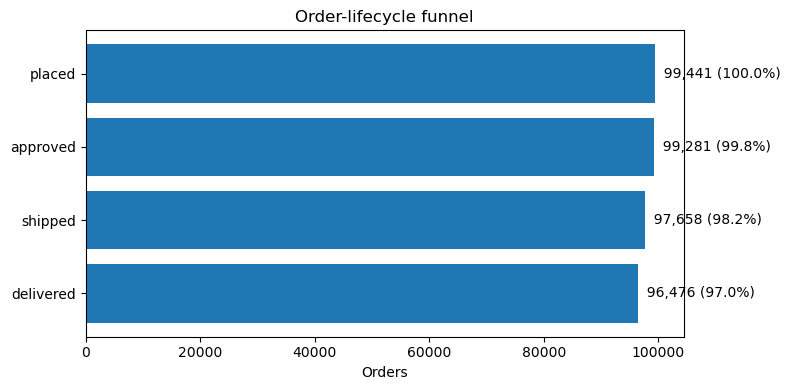

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(funnel_tidy["stage"], funnel_tidy["orders"])
ax.invert_yaxis()  # 'placed' on top
for i, (c, p) in enumerate(zip(funnel_tidy["orders"], funnel_tidy["pct_of_placed"])):
    ax.text(c, i, f"  {c:,} ({p}%)", va="center")
ax.set_xlabel("Orders")
ax.set_title("Order-lifecycle funnel")
plt.tight_layout()
plt.savefig("../reports/funnel.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. What did we find? 

Of 99,441 orders placed, 97% reach delivery. Fulfillment is healthy and not where customers are lost. The real leak is retention: only 3.1% of customers ever place a second order. The highest-leverage opportunity is driving repeat purchases, which the cohort analysis will examine next.